# Toxic Comments Classification - BiLSTM

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: JigsawToxic dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at Kaggle (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data). 


The comments are divided in two classes: toxic and normal.

Algorithme used: BiLSTM

Preprocessing techniques used:
* Lowercase
* Remove rare words
* Remove stop words
* Tokenization (accept all kind of tokens except spaces (carriage returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle, time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score, recall_score, f1_score, precision_score
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.model_selection import GridSearchCV,KFold
from sklearn.preprocessing import StandardScaler
from keras.wrappers.scikit_learn import KerasClassifier
from keras.layers import Dense, Input, Dropout
from keras import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing import text
import re
from nltk.corpus import stopwords
from datetime_extractor import DateTimeExtractor

from tensorflow.keras.layers import Dense, Embedding,GlobalMaxPooling1D, GlobalMaxPool1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM
from tensorflow.keras.layers import Embedding
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import to_categorical

import seaborn as sns
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set4.csv')
df.head()

,id,text,tox,tokenized
0,30351,2few recognize that refugee crisis & associate...,0,"['2few', 'recognize', 'that', 'refugee', 'cris..."
1,31565,@RandomRandomero @shoe0nhead Also shut up abou...,1,"['@', 'RandomRandomero', '@', 'shoe0nhead', 'A..."
2,764,WATCH: Democratic Senator Doesn't Understand T...,1,"['WATCH', ':', 'Democratic', 'Senator', 'Does'..."
3,2106,IS-puppets tried to roll me over three times! ...,1,"['IS-puppets', 'tried', 'to', 'roll', 'me', 'o..."
4,5979,WHO.. ARE. YOOUU? This is not mario kart. You ...,1,"['WHO', '..', 'ARE', '.', 'YOOUU', '?', 'This'..."


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set4.csv')
test.head()

,id,text,tox,tokenized
0,3816,#BuildThatWall #Meritbased get the ILLEGAL sit...,1,"['#', 'BuildThatWall', '#', 'Meritbased', 'get..."
1,2737,Angels Don't Die. I think it's better that two...,0,"['Angels', 'Do', ""n't"", 'Die', '.', 'I', 'thin..."
2,5598,When your girls actin a fool so you let your s...,1,"['When', 'your', 'girls', 'actin', 'a', 'fool'..."
3,19183,@PYS_FlyATL You pussy.,0,"['@', 'PYS_FlyATL', 'You', 'pussy', '.']"
4,1699,Tomorrow night our guest speaker is Madeleine ...,0,"['Tomorrow', 'night', 'our', 'guest', 'speaker..."


# 3. Preprocessing

In [4]:
def clean_text(comment): 

    comment = comment.lower() # Normalize to lowercase 
        
    return comment

In [5]:
# clean and normalize comments
df['text'] = df['text'].map(lambda word:clean_text(word))
test['text'] = test['text'].map(lambda word:clean_text(word))

In [6]:
# find the 10 most frequent words in the train data
dellist1 = pd.Series(' '.join(df['text']).split()).value_counts(ascending=True)[1:10]
print(dellist1)

overstays3.                1
@gperplexx                 1
@hmrcgovuk                 1
https://t.co/o46vjadazf    1
latinotech                 1
wisconsin                  1
predators                  1
@janeymack66               1
jamaica.                   1
dtype: int64


In [7]:
# remove the most frequent words from the train data
dellist1 = list(dellist1.index)
df['text'] = df['text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist1))
df.head()

,id,text,tox,tokenized
0,30351,2few recognize that refugee crisis & associate...,0,"['2few', 'recognize', 'that', 'refugee', 'cris..."
1,31565,@randomrandomero @shoe0nhead also shut up abou...,1,"['@', 'RandomRandomero', '@', 'shoe0nhead', 'A..."
2,764,watch: democratic senator doesn't understand t...,1,"['WATCH', ':', 'Democratic', 'Senator', 'Does'..."
3,2106,is-puppets tried to roll me over three times! ...,1,"['IS-puppets', 'tried', 'to', 'roll', 'me', 'o..."
4,5979,who.. are. yoouu? this is not mario kart. you ...,1,"['WHO', '..', 'ARE', '.', 'YOOUU', '?', 'This'..."


In [8]:
# find the 10 most frequent words in the test data
dellist2 = pd.Series(' '.join(test['text']).split()).value_counts(ascending=True)[1:10]
print(dellist2)

got!!                          1
(limited                       1
shaming                        1
mind.#walkawayfromdemocrats    1
😘😘😘                            1
platform?                      1
lenticular                     1
https://t.co/q6tlgrberm        1
cos                            1
dtype: int64


In [9]:
# remove the most frequent words from the test data
dellist2 = list(dellist2.index)
test['text'] = test['text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist2))
test.head()

,id,text,tox,tokenized
0,3816,#buildthatwall #meritbased get the illegal sit...,1,"['#', 'BuildThatWall', '#', 'Meritbased', 'get..."
1,2737,angels don't die. i think it's better that two...,0,"['Angels', 'Do', ""n't"", 'Die', '.', 'I', 'thin..."
2,5598,when your girls actin a fool so you let your s...,1,"['When', 'your', 'girls', 'actin', 'a', 'fool'..."
3,19183,@pys_flyatl you pussy.,0,"['@', 'PYS_FlyATL', 'You', 'pussy', '.']"
4,1699,tomorrow night our guest speaker is madeleine ...,0,"['Tomorrow', 'night', 'our', 'guest', 'speaker..."


In [10]:
stop_words = set(stopwords.words('english'))

In [11]:
print(stop_words)

{'are', 'does', 'each', 'more', 'on', 'only', "weren't", 'haven', 'has', 'such', "mightn't", 'yourself', 'did', 'from', 'm', 'him', 'by', 'its', 'between', 'an', 'y', 'been', "didn't", 'some', 'and', 'while', 'than', 'then', 'in', 'do', 'further', 'doing', 'both', 'doesn', 'themselves', 'before', 'up', "she's", 'so', 'when', 'whom', "won't", 't', 'ain', 'down', "you're", 'her', 'myself', 'or', 'them', 'at', 'too', 'is', 'through', 'couldn', 'the', 'with', 'here', "needn't", 'itself', 'to', 'of', 'we', 'that', 're', 'needn', "shouldn't", 'have', 'nor', 'she', "couldn't", 'ourselves', "hadn't", 'theirs', 'will', 'over', 'this', 'any', 'ma', 'had', 'all', 'there', 'don', 'out', 'should', 'weren', 'because', 'aren', "don't", 'but', 'having', 'same', "hasn't", 'ours', "it's", 'off', "you've", 'a', 'again', 'you', 'd', 'most', 'shan', 'your', 'how', "you'd", 'it', 'under', 'hadn', 'his', 'who', 'what', 's', "doesn't", 'himself', 'yours', 'll', 'our', 'were', 'they', 'own', 'herself', "haven'

In [12]:
def remove_stop_words(comment): 

    word_tokens = comment.split(' ') #word_tokenize(comment)
    
    filtered_comment = []  
    # converts the words in word_tokens tand tchecks whether 
    #they are present in stop_words or not
    for w in word_tokens:
        if w not in stop_words:
            filtered_comment.append(w)

    comment = (" ").join(filtered_comment)
    
    return comment

In [13]:
# clean and normalize comments
df['text'] = df['text'].map(lambda word:remove_stop_words(word))
test['text'] = test['text'].map(lambda word:remove_stop_words(word))

In [14]:
x_train, x_val, y_train, y_val = train_test_split(df['text'], df['tox'], test_size=0.15, random_state=42)

In [15]:
#Check shape of train data
print(x_train.shape)
print(y_train.shape)

(8840,)
(8840,)


In [16]:
#Check shape of validation data
print(x_val.shape)
print(y_val.shape)

(1560,)
(1560,)


In [17]:
x_test = test['text']
y_test = test['tox']

#Check shape of data
print(x_test.shape)
print(y_test.shape)

(2600,)
(2600,)


### Vectorize texts

In [18]:
# Create vocabulary with training texts.
tokenizer = text.Tokenizer(num_words=20000, filters='\r\t\n', lower=False)  # Limit on the number of features. We use the top 20K features.
tokenizer.fit_on_texts(list(x_train)+ list(x_val) + list(x_test))

# Vectorize training texts.
tokenized_train = tokenizer.texts_to_sequences(x_train)
tokenized_val = tokenizer.texts_to_sequences(x_val)
tokenized_test = tokenizer.texts_to_sequences(x_test)

In [19]:
# Limit on the length of text sequences. Sequences longer than this
# will be truncated.
MAX_SEQUENCE_LENGTH = 100


# Get max sequence length.
max_length = len(max(x_train, key=len))
if max_length > MAX_SEQUENCE_LENGTH:
       max_length = MAX_SEQUENCE_LENGTH

In [20]:
# Fix sequence length to max value. Sequences shorter than the length are
# padded in the end and sequences longer are truncated
# at the end.
X_train = pad_sequences(tokenized_train, maxlen=max_length, padding= 'post')
X_val = pad_sequences(tokenized_val, maxlen=max_length, padding= 'post')
X_test = pad_sequences(tokenized_test, maxlen=max_length, padding= 'post')

In [21]:
# Get length of corpus's word index
vocab_size=(len(tokenizer.word_index)+1)
print(vocab_size)

46477


###  converts a class vector (integers) to binary class matrix.

In [22]:
# converts a class vector (integers) to binary class matrix.
Y_train=to_categorical(y_train)
#Check shape of data
Y_train.shape

(8840, 2)

In [23]:
# converts a class vector (integers) to binary class matrix.
Y_val=to_categorical(y_val)
#Check shape of data
Y_val.shape

(1560, 2)

In [24]:
# converts a class vector (integers) to binary class matrix.
Y_test=to_categorical(y_test)
#Check shape of data
Y_test.shape

(2600, 2)

In [25]:
Y_val[:2]

array([[1., 0.],
       [0., 1.]], dtype=float32)

In [26]:
Y_test[:2]

array([[0., 1.],
       [1., 0.]], dtype=float32)

In [27]:
Y_train[:2]

array([[1., 0.],
       [1., 0.]], dtype=float32)

# 3. Create model

In [28]:
EMBEDDING_DIM=400

def model_to_optimize(optimizer='RMSprop'): #learning_rate = 0.001 default value
         
    model = Sequential()
    
    seq = Input(shape=(max_length,))
    input_seq = Embedding(
        input_dim = vocab_size, input_length = max_length,output_dim = EMBEDDING_DIM)(seq)
    
    layer = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(input_seq)
    layer = GlobalMaxPool1D()(layer)
    output = Dense(2, activation='softmax')(layer) 
        
    model = Model(inputs=seq, outputs=output)
        
    model.compile(loss='binary_crossentropy',optimizer=optimizer, metrics=['accuracy'])
    return model

In [29]:
from keras import backend, Model

model_used = model_to_optimize()
# summarize model
model_used.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 100)]             0         
_________________________________________________________________
embedding (Embedding)        (None, 100, 400)          18590800  
_________________________________________________________________
bidirectional (Bidirectional (None, 100, 128)          238080    
_________________________________________________________________
global_max_pooling1d (Global (None, 128)               0         
_________________________________________________________________
dense (Dense)                (None, 2)                 258       
Total params: 18,829,138
Trainable params: 18,829,138
Non-trainable params: 0
_________________________________________________________________


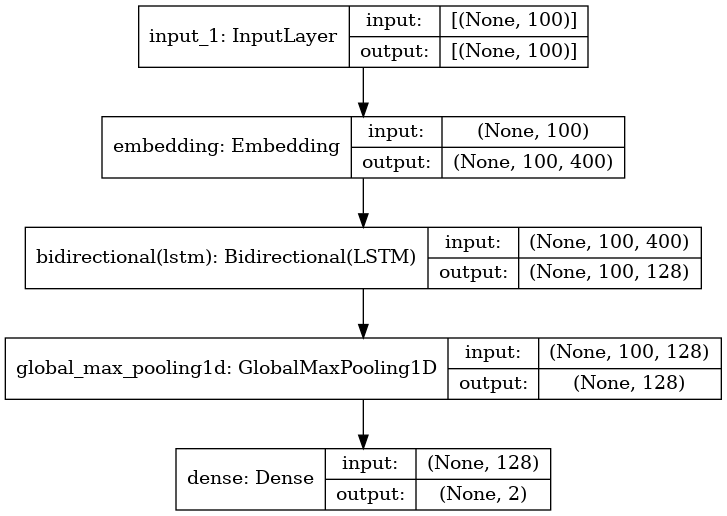

In [30]:
# plot model
plot_model(model_used, show_shapes=True)

In [31]:
## Define your callbacks
Modle_Checkpoint = ModelCheckpoint(
    'modles/bilstm_approach#16.h5',
    monitor='val_loss',
    save_best_only='True',
    mode='min',
    verbose=1
)

Early_Stopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    verbose=1,
    restore_best_weights='True',
    min_delta=0
)

In [32]:
callbacks = [Early_Stopping, Modle_Checkpoint, ]

### Train classifier

In [33]:
history = model_used.fit(X_train,Y_train, epochs=100,
                            callbacks=callbacks,
                            batch_size=128, #litterature review
                            validation_data=(X_val, Y_val),
                            verbose=True)

Epoch 1/100
70/70 [==============================] - 124s 2s/step - loss: 0.6196 - accuracy: 0.6480 - val_loss: 0.6175 - val_accuracy: 0.6737

Epoch 00001: val_loss improved from inf to 0.61749, saving model to modles/bilstm_approach#16.h5
Epoch 2/100
70/70 [==============================] - 98s 1s/step - loss: 0.4510 - accuracy: 0.7896 - val_loss: 0.5662 - val_accuracy: 0.7256

Epoch 00002: val_loss improved from 0.61749 to 0.56623, saving model to modles/bilstm_approach#16.h5
Epoch 3/100
70/70 [==============================] - 115s 2s/step - loss: 0.3403 - accuracy: 0.8559 - val_loss: 0.6558 - val_accuracy: 0.7237

Epoch 00003: val_loss did not improve from 0.56623
Epoch 4/100
70/70 [==============================] - 132s 2s/step - loss: 0.2580 - accuracy: 0.8959 - val_loss: 0.7032 - val_accuracy: 0.6981

Epoch 00004: val_loss did not improve from 0.56623
Epoch 5/100
70/70 [==============================] - 129s 2s/step - loss: 0.2025 - accuracy: 0.9221 - val_loss: 0.7809 - val_accu

### Evaluate metrics

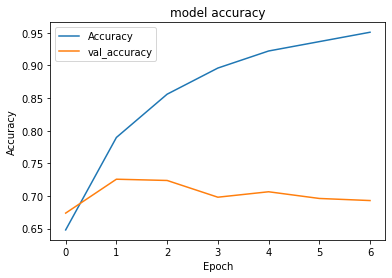

In [34]:
import matplotlib.pyplot as plt
hist = history.history
plt.plot(hist["accuracy"])
plt.plot(hist['val_accuracy'])
plt.title("model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy","val_accuracy"])
plt.show()

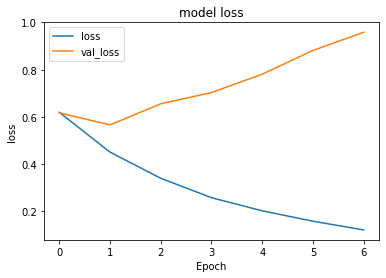

In [35]:
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("Epoch")
plt.legend(["loss","val_loss"])
plt.show()

In [36]:
from keras.models import load_model
saved_model = load_model("modles/bilstm_approach#16.h5")

result = saved_model.evaluate(X_train,Y_train,
                               batch_size=128, #litterature review
                            verbose=True)


70/70 [==============================] - 20s 268ms/step - loss: 0.3497 - accuracy: 0.8633


In [37]:
print("train loss: %0.3f" % result[0])
print("train acc: %0.3f" % result[1])

train loss: 0.350
train acc: 0.863


In [38]:
result_val = saved_model.evaluate(X_val,Y_val,
                               batch_size=128, #litterature review
                            verbose=True)

13/13 [==============================] - 3s 249ms/step - loss: 0.5662 - accuracy: 0.7256


In [39]:
print("validation loss: %0.3f" % result_val[0])
print("validation acc: %0.3f" % result_val[1])

validation loss: 0.566
validation acc: 0.726


In [40]:
train_accuracy = "%.4f" % (result[1])
train_Loss = r"%.4f" % (result[0])
val_accuracy = "%.4f" % (result_val[1])
val_loss = "%.4f" % (result_val[0])

# 4. Predictions

### Test set

In [41]:
y_pred=saved_model.predict(X_test, batch_size=128, verbose=True)

21/21 [==============================] - 6s 255ms/step


In [42]:
print(y_pred)

[[0.00165221 0.99834776]
 [0.99308395 0.00691599]
 [0.00485767 0.99514234]
 ...
 [0.56610006 0.4338999 ]
 [0.913141   0.08685903]
 [0.4417128  0.5582872 ]]


In [43]:
print(Y_train)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [44]:
print(Y_test)

[[0. 1.]
 [1. 0.]
 [0. 1.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [45]:
print("\n Accuracy: %0.2f" % accuracy_score(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))
print("\n Confusion matrix\n")
print(classification_report(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))


 Accuracy: 0.73

 Confusion matrix

              precision    recall  f1-score   support

           0       0.79      0.70      0.74      1465
           1       0.66      0.76      0.71      1135

    accuracy                           0.73      2600
   macro avg       0.73      0.73      0.73      2600
weighted avg       0.74      0.73      0.73      2600



In [46]:
y_pred=np.argmax(y_pred, axis=1)
Y_test=np.argmax(Y_test, axis=1)
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[1027  438]
 [ 272  863]]


In [47]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, y_pred))
test_recall  = "%.4f" % (recall_score(Y_test, y_pred))
test_F1_score  = "%.4f" % (f1_score(Y_test, y_pred))
test_precision  = "%.4f" % (precision_score(Y_test, y_pred))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.7269
recall :  0.7604
F1_score :  0.7085
precision :  0.6633


# 5. Save results to Excel file

In [48]:
# define tarjet
newFile = "../results_BiLSTM_set4.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #16', 2:train_accuracy, 3:train_Loss, 4:val_accuracy, 5:val_loss, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach#1
index = 18

# delete row of approach#1
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)